# 🔬 Notebook 08: Module 6 — Dimensionality Reduction
## PCA, LDA, SVD Feature Extraction & Classification Impact

In [1]:
import sys
import os
import time
import warnings
warnings.filterwarnings("ignore")

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

from src.utils import load_numpy, save_model, load_model
from src.dimensionality_reduction import (
    apply_pca,
    apply_lda,
    apply_svd,
    find_optimal_pca_components
)

X_train = load_numpy(os.path.join(PROJECT_ROOT, "data", "processed", "X_train.npy"))
X_test = load_numpy(os.path.join(PROJECT_ROOT, "data", "processed", "X_test.npy"))

y_train_bin = load_numpy(os.path.join(PROJECT_ROOT, "data", "processed", "y_train_binary.npy"))
y_test_bin = load_numpy(os.path.join(PROJECT_ROOT, "data", "processed", "y_test_binary.npy"))

y_train_multi = load_numpy(os.path.join(PROJECT_ROOT, "data", "processed", "y_train_multi.npy"))
y_test_multi = load_numpy(os.path.join(PROJECT_ROOT, "data", "processed", "y_test_multi.npy"))

le_multi = load_model(os.path.join(PROJECT_ROOT, "models", "encoders", "label_encoder_multi.pkl"))
class_names = list(le_multi.classes_)

sub_idx = np.random.choice(len(X_train), 15000, replace=False)
X_sub = X_train[sub_idx]
y_sub_bin = y_train_bin[sub_idx]
y_sub_multi = y_train_multi[sub_idx]

📂 Array loaded: d:\WebDev\Network_Intrusion_Detection\data\processed\X_train.npy | Shape: (125973, 122)
📂 Array loaded: d:\WebDev\Network_Intrusion_Detection\data\processed\X_test.npy | Shape: (22544, 122)
📂 Array loaded: d:\WebDev\Network_Intrusion_Detection\data\processed\y_train_binary.npy | Shape: (125973,)
📂 Array loaded: d:\WebDev\Network_Intrusion_Detection\data\processed\y_test_binary.npy | Shape: (22544,)
📂 Array loaded: d:\WebDev\Network_Intrusion_Detection\data\processed\y_train_multi.npy | Shape: (125973,)
📂 Array loaded: d:\WebDev\Network_Intrusion_Detection\data\processed\y_test_multi.npy | Shape: (22544,)
📂 Model loaded: d:\WebDev\Network_Intrusion_Detection\models\encoders\label_encoder_multi.pkl


In [2]:
t0 = time.time()
base_svm = SVC(kernel="rbf", C=1.0, random_state=42)
base_svm.fit(X_sub, y_sub_bin)
base_train_time = time.time() - t0

base_preds = base_svm.predict(X_test)
base_acc = accuracy_score(y_test_bin, base_preds)
base_f1 = f1_score(y_test_bin, base_preds)

print(f"Full Features ({X_sub.shape[1]} dims) - Accuracy: {base_acc:.4f}, F1: {base_f1:.4f}, Time: {base_train_time:.2f}s")

Full Features (122 dims) - Accuracy: 0.7750, F1: 0.7611, Time: 1.74s


Components for 90% variance: 17
Components for 95% variance: 21
Components for 99% variance: 35


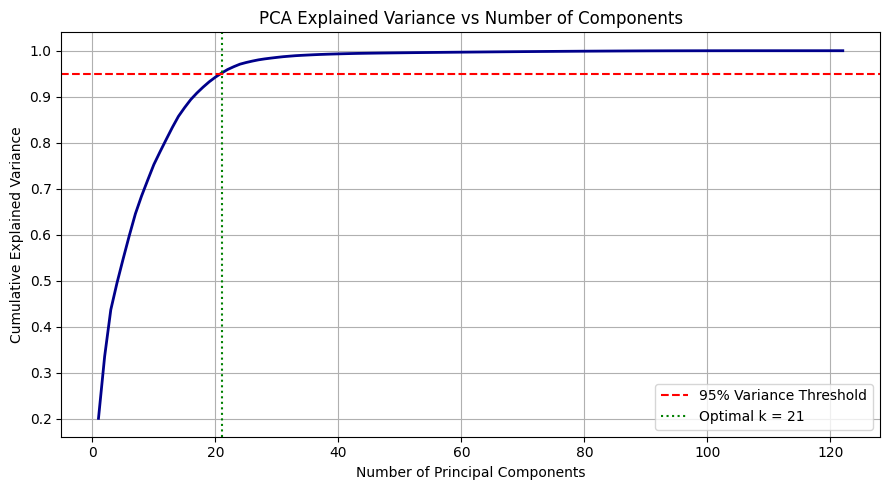

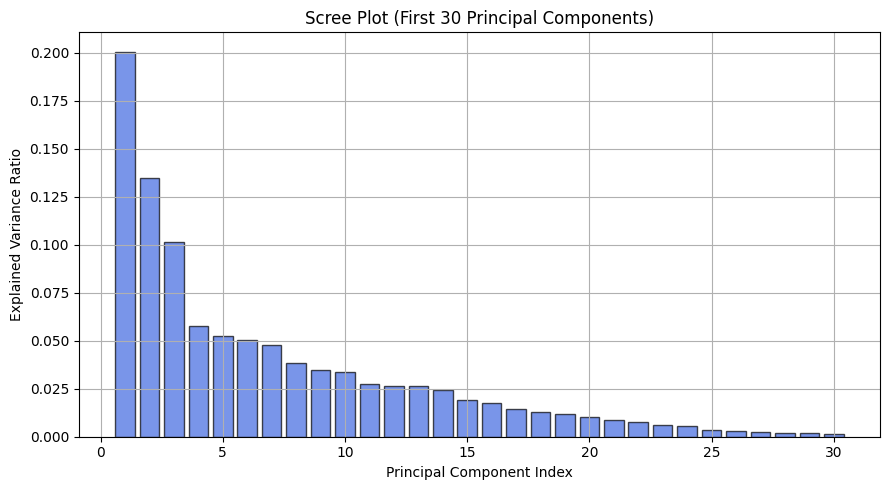

In [3]:
optimal_k_95, exp_var, cum_var = find_optimal_pca_components(X_sub, variance_threshold=0.95)
optimal_k_90 = int(np.argmax(cum_var >= 0.90) + 1)
optimal_k_99 = int(np.argmax(cum_var >= 0.99) + 1)

print(f"Components for 90% variance: {optimal_k_90}")
print(f"Components for 95% variance: {optimal_k_95}")
print(f"Components for 99% variance: {optimal_k_99}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(cum_var) + 1), cum_var, color="darkblue", linewidth=2)
ax.axhline(0.95, color="red", linestyle="--", label="95% Variance Threshold")
ax.axvline(optimal_k_95, color="green", linestyle=":", label=f"Optimal k = {optimal_k_95}")
ax.set_xlabel("Number of Principal Components")
ax.set_ylabel("Cumulative Explained Variance")
ax.set_title("PCA Explained Variance vs Number of Components")
ax.legend()
ax.grid(True)
plt.tight_layout()
fig.savefig(os.path.join(PROJECT_ROOT, "plots", "module6", "pca_explained_variance.png"), dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(range(1, 31), exp_var[:30], color="royalblue", edgecolor="k", alpha=0.7)
ax.set_xlabel("Principal Component Index")
ax.set_ylabel("Explained Variance Ratio")
ax.set_title("Scree Plot (First 30 Principal Components)")
ax.grid(True)
plt.tight_layout()
fig.savefig(os.path.join(PROJECT_ROOT, "plots", "module6", "scree_plot.png"), dpi=150)
plt.show()

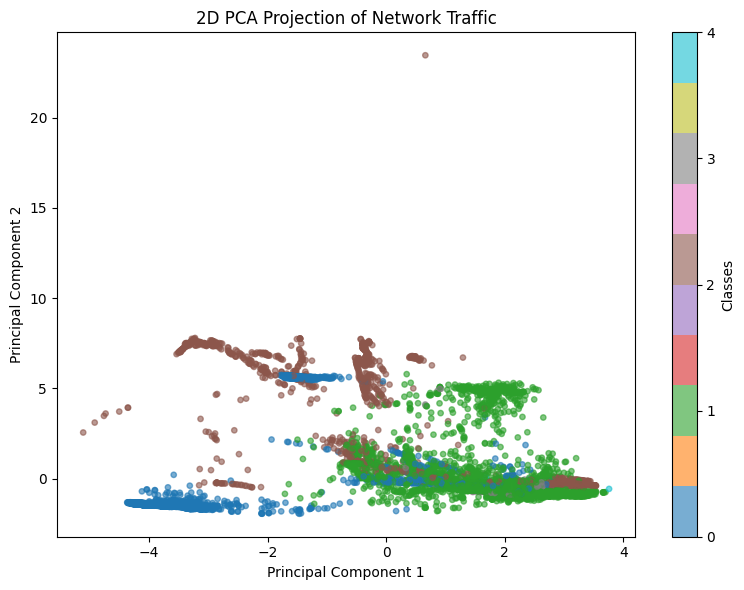

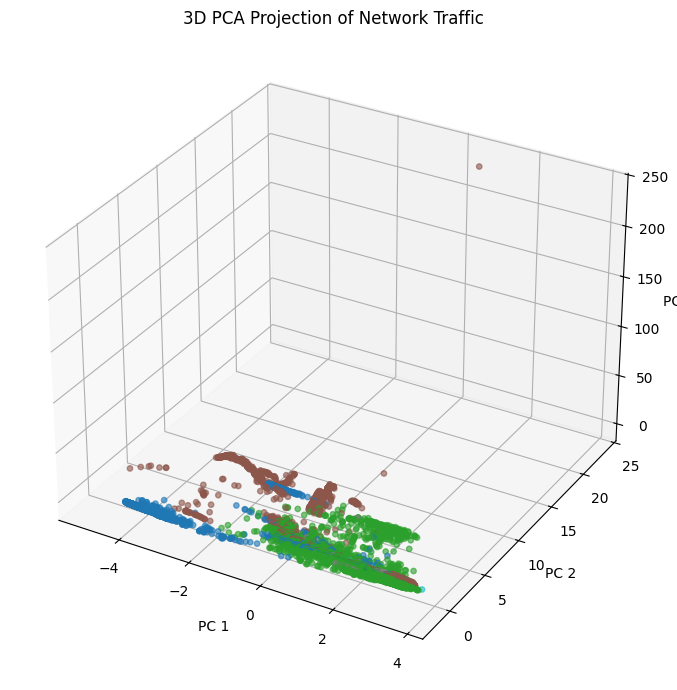

In [4]:
pca_vis, X_sub_pca_vis, _ = apply_pca(X_sub, X_test, n_components=3)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_sub_pca_vis[:, 0], X_sub_pca_vis[:, 1], c=y_sub_multi, cmap="tab10", s=15, alpha=0.6)
ax.set_title("2D PCA Projection of Network Traffic")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
plt.colorbar(scatter, ticks=range(len(class_names)), label="Classes")
plt.tight_layout()
fig.savefig(os.path.join(PROJECT_ROOT, "plots", "module6", "pca_2d_projection.png"), dpi=150)
plt.show()

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
scatter = ax.scatter(X_sub_pca_vis[:, 0], X_sub_pca_vis[:, 1], X_sub_pca_vis[:, 2], c=y_sub_multi, cmap="tab10", s=15, alpha=0.6)
ax.set_title("3D PCA Projection of Network Traffic")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_zlabel("PC 3")
plt.tight_layout()
fig.savefig(os.path.join(PROJECT_ROOT, "plots", "module6", "pca_3d_projection.png"), dpi=150)
plt.show()

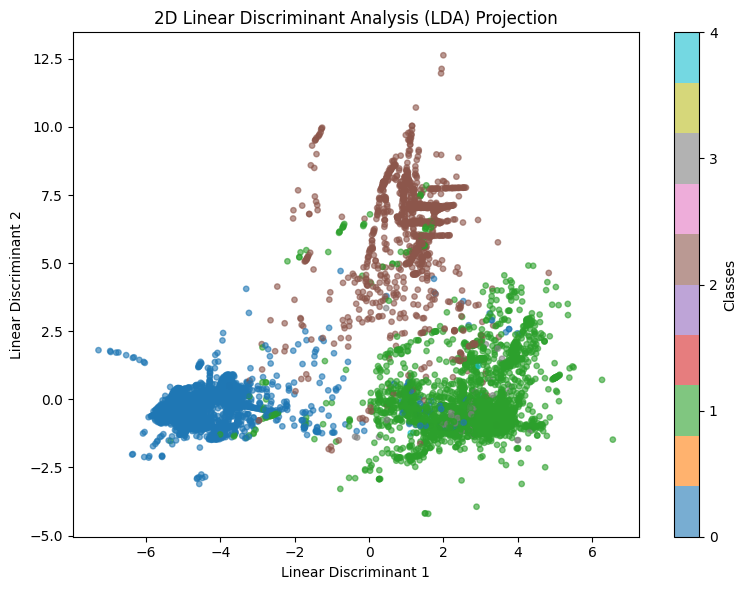

In [5]:
lda_vis, X_sub_lda_vis, _ = apply_lda(X_sub, y_sub_multi, X_test, n_components=4)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_sub_lda_vis[:, 0], X_sub_lda_vis[:, 1], c=y_sub_multi, cmap="tab10", s=15, alpha=0.6)
ax.set_title("2D Linear Discriminant Analysis (LDA) Projection")
ax.set_xlabel("Linear Discriminant 1")
ax.set_ylabel("Linear Discriminant 2")
plt.colorbar(scatter, ticks=range(len(class_names)), label="Classes")
plt.tight_layout()
fig.savefig(os.path.join(PROJECT_ROOT, "plots", "module6", "lda_projection.png"), dpi=150)
plt.show()

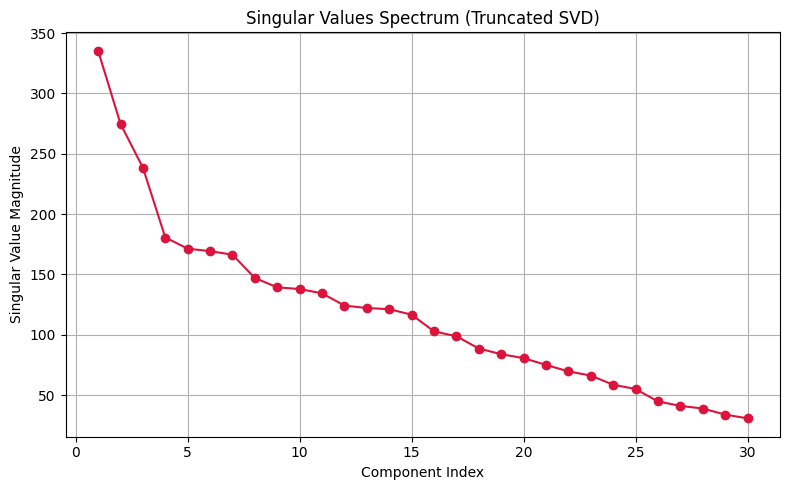

In [6]:
svd_model, X_sub_svd, X_test_svd = apply_svd(X_sub, X_test, n_components=30)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, 31), svd_model.singular_values_, marker="o", color="crimson")
ax.set_xlabel("Component Index")
ax.set_ylabel("Singular Value Magnitude")
ax.set_title("Singular Values Spectrum (Truncated SVD)")
ax.grid(True)
plt.tight_layout()
fig.savefig(os.path.join(PROJECT_ROOT, "plots", "module6", "svd_components.png"), dpi=150)
plt.show()

In [7]:
component_counts = [5, 10, 20, optimal_k_95]
comparison_rows = []

comparison_rows.append({
    "Method": "Baseline (None)",
    "Dimensions": X_sub.shape[1],
    "Accuracy": base_acc,
    "F1-Score": base_f1,
    "Train Time (s)": base_train_time,
    "Speedup": 1.0
})

for k in component_counts:
    pca_m, X_tr_p, X_te_p = apply_pca(X_sub, X_test, n_components=k)
    t0 = time.time()
    clf = SVC(kernel="rbf", C=1.0, random_state=42)
    clf.fit(X_tr_p, y_sub_bin)
    t_train = time.time() - t0
    preds = clf.predict(X_te_p)
    
    comparison_rows.append({
        "Method": f"PCA-{k}",
        "Dimensions": k,
        "Accuracy": accuracy_score(y_test_bin, preds),
        "F1-Score": f1_score(y_test_bin, preds),
        "Train Time (s)": t_train,
        "Speedup": base_train_time / t_train if t_train > 0 else 0.0
    })

for k in component_counts:
    svd_m, X_tr_s, X_te_s = apply_svd(X_sub, X_test, n_components=k)
    t0 = time.time()
    clf = SVC(kernel="rbf", C=1.0, random_state=42)
    clf.fit(X_tr_s, y_sub_bin)
    t_train = time.time() - t0
    preds = clf.predict(X_te_s)
    
    comparison_rows.append({
        "Method": f"SVD-{k}",
        "Dimensions": k,
        "Accuracy": accuracy_score(y_test_bin, preds),
        "F1-Score": f1_score(y_test_bin, preds),
        "Train Time (s)": t_train,
        "Speedup": base_train_time / t_train if t_train > 0 else 0.0
    })

lda_m, X_tr_l, X_te_l = apply_lda(X_sub, y_sub_multi, X_test, n_components=4)
t0 = time.time()
clf = SVC(kernel="rbf", C=1.0, random_state=42)
clf.fit(X_tr_l, y_sub_bin)
t_train = time.time() - t0
preds = clf.predict(X_te_l)

comparison_rows.append({
    "Method": "LDA-4",
    "Dimensions": 4,
    "Accuracy": accuracy_score(y_test_bin, preds),
    "F1-Score": f1_score(y_test_bin, preds),
    "Train Time (s)": t_train,
    "Speedup": base_train_time / t_train if t_train > 0 else 0.0
})

comp_df = pd.DataFrame(comparison_rows)
print(comp_df)
comp_df.to_csv(os.path.join(PROJECT_ROOT, "results", "dimensionality_reduction_comparison.csv"), index=False)

best_pca, _, _ = apply_pca(X_train, X_test, n_components=optimal_k_95)
best_svd, _, _ = apply_svd(X_train, X_test, n_components=optimal_k_95)
best_lda, _, _ = apply_lda(X_train, y_train_multi, X_test, n_components=4)

save_model(best_pca, os.path.join(PROJECT_ROOT, "models", "saved_models", "pca_model.pkl"))
save_model(best_svd, os.path.join(PROJECT_ROOT, "models", "saved_models", "svd_model.pkl"))
save_model(best_lda, os.path.join(PROJECT_ROOT, "models", "saved_models", "lda_model.pkl"))

            Method  Dimensions  Accuracy  F1-Score  Train Time (s)   Speedup
0  Baseline (None)         122  0.775018  0.761070        1.743647  1.000000
1            PCA-5           5  0.738112  0.717323        1.287223  1.354580
2           PCA-10          10  0.738112  0.720428        1.037857  1.680046
3           PCA-20          20  0.769828  0.762310        0.519531  3.356194
4           PCA-21          21  0.771114  0.763281        0.633735  2.751381
5            SVD-5           5  0.738822  0.718547        0.438746  3.974158
6           SVD-10          10  0.737491  0.718780        0.439331  3.968870
7           SVD-20          20  0.758162  0.747195        0.568631  3.066393
8           SVD-21          21  0.769207  0.761516        0.544171  3.204227
9            LDA-4           4  0.761178  0.750371        0.284482  6.129189
💾 Model saved: d:\WebDev\Network_Intrusion_Detection\models\saved_models\pca_model.pkl
💾 Model saved: d:\WebDev\Network_Intrusion_Detection\models\saved_

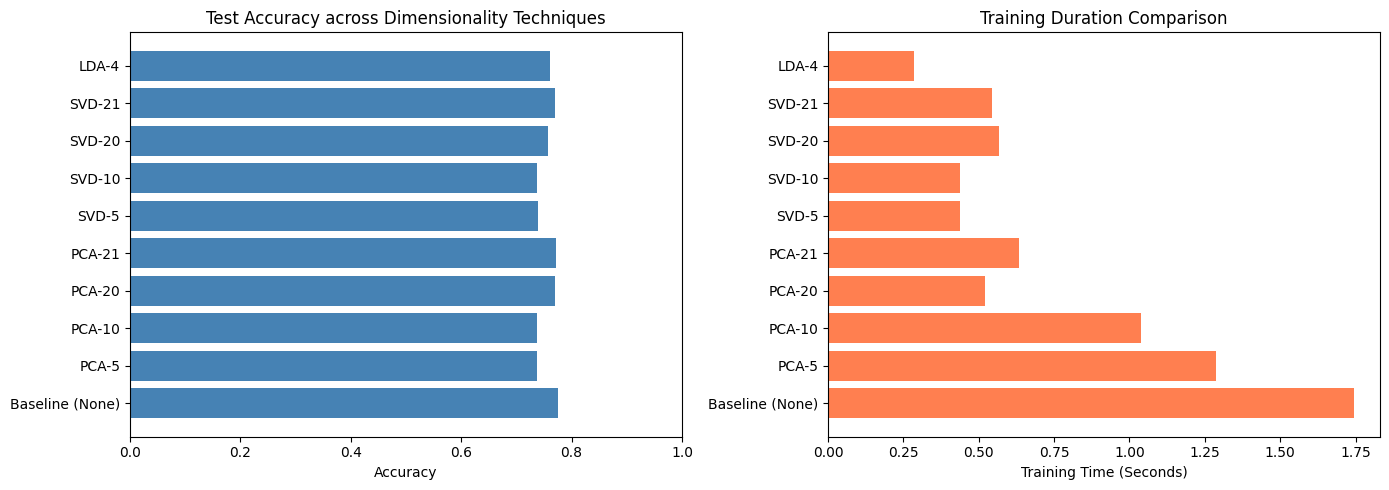

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(comp_df["Method"], comp_df["Accuracy"], color="steelblue")
axes[0].set_xlabel("Accuracy")
axes[0].set_title("Test Accuracy across Dimensionality Techniques")
axes[0].set_xlim(0, 1.0)

axes[1].barh(comp_df["Method"], comp_df["Train Time (s)"], color="coral")
axes[1].set_xlabel("Training Time (Seconds)")
axes[1].set_title("Training Duration Comparison")

plt.tight_layout()
fig.savefig(os.path.join(PROJECT_ROOT, "plots", "module6", "before_after_accuracy.png"), dpi=150)
plt.show()